Introduction:

Sabrina and I are Microbiology majors, and have served as teaching assistants for MCB3023L; a core Microbiology laboratory class. A key part of the class is the lab practical, which constitutes a large part of the students' grades. It is notorious for being long and difficult.

We wanted to investigate factors potentially related to performance on the lab practical so that we could help our professor and her future students.

Data Collection:

We started off by creating a survey for MCB3023L asking several questions related to 1) their letter grade performance on the practical and 2) their studying/learning habits related to the lab practical.


Now, to help you get an idea of what the survey was like, here is a look at the questions asked on the survey: 

How often did you pay close attention during lab sessions?

How many times did you come into the lab outside of class to practice techniques?

How confident were you in your lab techniques before the practical? (rate 1-5 )

How anxious were you about the lab practical? (rate 1-5 )

How many hours per week did you study or review lab materials?

Helpfulness in Studying: Lab Manual (rate 1-5 stars)

Helpfulness in Studying: Quizlet (rate 1-5 stars)

Helpfulness in Studying: Lab Slides (rate 1-5 stars)

Helpfulness in Studying: ELNs (rate 1-5 stars)

Helpfulness in Studying: ChatGPT (rate 1-5 stars)

Do you or have you worked or volunteered in a lab setting outside of MCB3023L? (yes or no)

What grade did you receive on the lab practical? ← (Target!! What we want to predict!! Asked as Letter Grade, not Numerical grade)

We then had to obtain IRB-exemption (since we were collecting data off of people) and sponsorship from our professor of whom we TA'd for. It could be argued that we don't actually need this since this is for educational purposes and not for research publication, but we decided we would do this for ethical purposes, just in case. 

Additionally, all the data collected was anonymous.


Survey Distribution: 

The next part involved contacting three professors who teach MCB3023L and requesting they distribute the survey to their students. It was the most essential part of our project. Without data, we don't really have a solid project. Additionally, the number of responses we got largely impacts what models we can even consider using. 

We ended up collecting 82 responses total. Was it what we wanted? No. But this is how the real world works sometimes, and so we had to make do. 

Because of how many responses we got, we decided we could NOT use a deep neural network. We would have to stick with using Logistic Regression, Random Forest, and Decision Trees.

## Data Preprocessing: Load & Clean Columns

Okay so first we’re loading in the CSV file from our survey. Some of the column names are way too long and arguably annoying to work with, so we’re renaming them to something easier. We’re also dropping the timestamp and the confirmation checkbox since they’re not useful for our analysis. Those are just the questions that address when the person took the survey and if they want to take the survey.


In [51]:
import pandas as pd

# Load the raw CSV file
df = pd.read_csv("MCB3032L (Responses) - Form Responses final.csv")

# Rename columns to something more readable
df.columns = [
    "timestamp",
    "attention_during_lab",
    "lab_practice_times",
    "confidence_before_practical",
    "anxiety_about_practical",
    "study_hours_per_week",
    "helpfulness_lab_manual",
    "helpfulness_quizlet",
    "helpfulness_lab_slides",
    "helpfulness_eln",
    "helpfulness_chatgpt",
    "prior_lab_experience",
    "lab_practical_grade",
    "survey_confirmation"
]

# Drop unnecessary columns
df = df.drop(columns=["timestamp", "survey_confirmation"], errors="ignore")

# Display the first few rows
df.head()


,attention_during_lab,lab_practice_times,confidence_before_practical,anxiety_about_practical,study_hours_per_week,helpfulness_lab_manual,helpfulness_quizlet,helpfulness_lab_slides,helpfulness_eln,helpfulness_chatgpt,prior_lab_experience,lab_practical_grade
0,most of the time,0 times,5,3,less than 1 hour,3.0,1.0,4.0,5,1.0,yes,A (90-100)
1,most of the time,2-3 times,5,2,1-2 hours,1.0,1.0,2.0,1,1.0,yes,D (60-69)
2,most of the time,2-3 times,4,2,1-2 hours,3.0,1.0,5.0,5,4.0,yes,B (80-89)
3,most of the time,2-3 times,3,3,less than 1 hour,2.0,2.0,5.0,4,1.0,yes,B (80-89)
4,most of the time,2-3 times,3,5,less than 1 hour,2.0,1.0,3.0,4,4.0,yes,B (80-89)


## Converting Survey Answers to Numbers

Now we’re going to convert the written responses into numbers. Stuff like “most of the time” and “1-2 hours” needs to be mapped to something a model can understand, as well as to keep some continuity aspects. We made custom mappings for each of these based on how they rank in terms of effort or frequency by making them averages (eg 1-2 hours represented as 1.5 hours)

One example important to note is that we changed the yes or no to binary because the model is not going to understand yes or no, but it will understand 1 and 0s.

We also cleaned up the grade column so it just says A, B, C, D, or F.


In [52]:
# Define mappings
attention_map = {
    "always": 5,
    "most of the time": 4,
    "sometimes": 3,
    "rarely": 2,
    "never": 1
}

lab_practice_map = {
    "0 times": 0,
    "1 time": 1,
    "2-3 times": 2.5,
    "4-5 times": 4.5,
    "6+ times": 6
}

study_hours_map = {
    "less than 1 hour": 0.5,
    "1-2 hours": 1.5,
    "3-4 hours": 3.5,
    "5+ hours": 5
}

lab_experience_map = {
    "yes": 1,
    "no": 0
}

# Apply the mappings
df["attention_during_lab"] = df["attention_during_lab"].str.strip().str.lower().map(attention_map)
df["lab_practice_times"] = df["lab_practice_times"].str.strip().map(lab_practice_map)
df["study_hours_per_week"] = df["study_hours_per_week"].str.strip().map(study_hours_map)
df["prior_lab_experience"] = df["prior_lab_experience"].str.strip().str.lower().map(lab_experience_map)
df["lab_practical_grade"] = df["lab_practical_grade"].str.extract(r'([A-F])')

# Check the cleaned version
df.head()


,attention_during_lab,lab_practice_times,confidence_before_practical,anxiety_about_practical,study_hours_per_week,helpfulness_lab_manual,helpfulness_quizlet,helpfulness_lab_slides,helpfulness_eln,helpfulness_chatgpt,prior_lab_experience,lab_practical_grade
0,4,0.0,5,3,0.5,3.0,1.0,4.0,5,1.0,1,A
1,4,2.5,5,2,1.5,1.0,1.0,2.0,1,1.0,1,D
2,4,2.5,4,2,1.5,3.0,1.0,5.0,5,4.0,1,B
3,4,2.5,3,3,0.5,2.0,2.0,5.0,4,1.0,1,B
4,4,2.5,3,5,0.5,2.0,1.0,3.0,4,4.0,1,B



## Handling Missing Values

Since we don’t have a ton of data, we can’t just drop rows that have missing values. So instead, we’ll fill in the missing stuff.

- For number-based questions (like study hours or confidence), we’ll fill missing values with the **median**.
- If anyone didn’t report their **grade**, we’ll drop just that row — we can’t use it to train the model anyway.


In [53]:
# Check where NaNs are
print("Missing values per column:\n")
print(df.isnull().sum())

# Fill numeric columns with the median
num_cols = df.select_dtypes(include=["float64", "int64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# If any rows are missing the target grade, drop those (we can't train on them)
df = df.dropna(subset=["lab_practical_grade"])

# Check again
print("\nAny missing values left?", df.isnull().values.any())
print(f"Final dataset shape: {df.shape}")


Missing values per column:

attention_during_lab           0
lab_practice_times             0
confidence_before_practical    0
anxiety_about_practical        0
study_hours_per_week           0
helpfulness_lab_manual         1
helpfulness_quizlet            2
helpfulness_lab_slides         2
helpfulness_eln                0
helpfulness_chatgpt            3
prior_lab_experience           0
lab_practical_grade            6
dtype: int64

Any missing values left? False
Final dataset shape: (76, 12)


## Quick Visuals to Explore the Data

Before we build any models, it’s a good idea to look at the data a bit. Here’s a bar chart showing how many people got each grade, and a boxplot that shows if there’s any pattern between how many hours people studied and what grade they got.


/tmp/ipykernel_2378/1166850151.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="lab_practical_grade", data=df, order=["A", "B", "C", "D", "F"], palette="viridis")


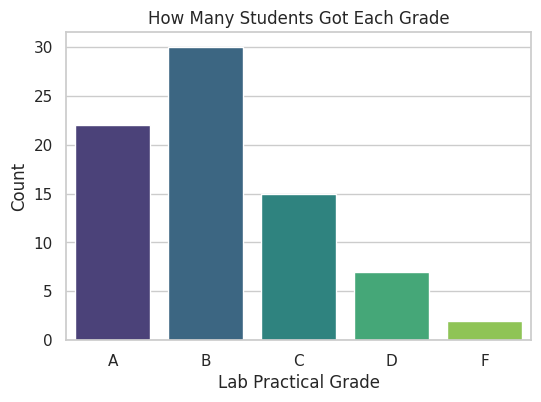

/tmp/ipykernel_2378/1166850151.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="lab_practical_grade", y="study_hours_per_week", data=df, order=["A", "B", "C", "D", "F"], palette="pastel")


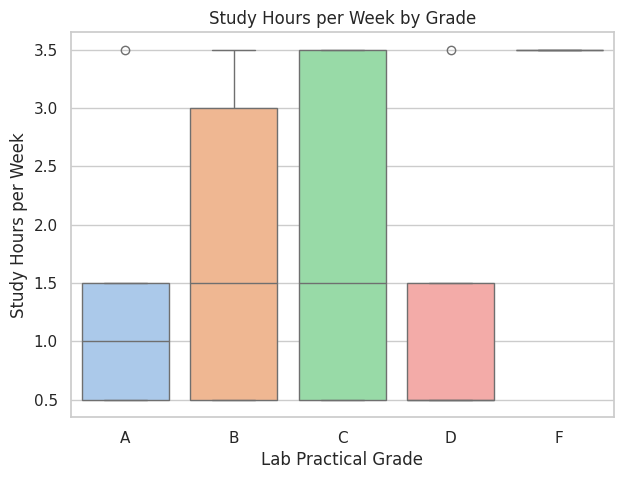

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Bar plot: count of each grade
plt.figure(figsize=(6, 4))
sns.countplot(x="lab_practical_grade", data=df, order=["A", "B", "C", "D", "F"], palette="viridis")
plt.title("How Many Students Got Each Grade")
plt.xlabel("Lab Practical Grade")
plt.ylabel("Count")
plt.show()

# Boxplot: study hours vs grade
plt.figure(figsize=(7, 5))
sns.boxplot(x="lab_practical_grade", y="study_hours_per_week", data=df, order=["A", "B", "C", "D", "F"], palette="pastel")
plt.title("Study Hours per Week by Grade")
plt.xlabel("Lab Practical Grade")
plt.ylabel("Study Hours per Week")
plt.show()


## Looking at All the Features Together

We’re going to make a pairplot now. It shows all the relationships between our features (like confidence, anxiety, study hours, etc.). The dots are colored by what grade the student got. 

This is helpful to spot patterns — like whether higher study hours and confidence cluster around A’s, or if anxiety is all over the place. Even if we don’t get perfect separation, it gives us an idea of what features might matter.


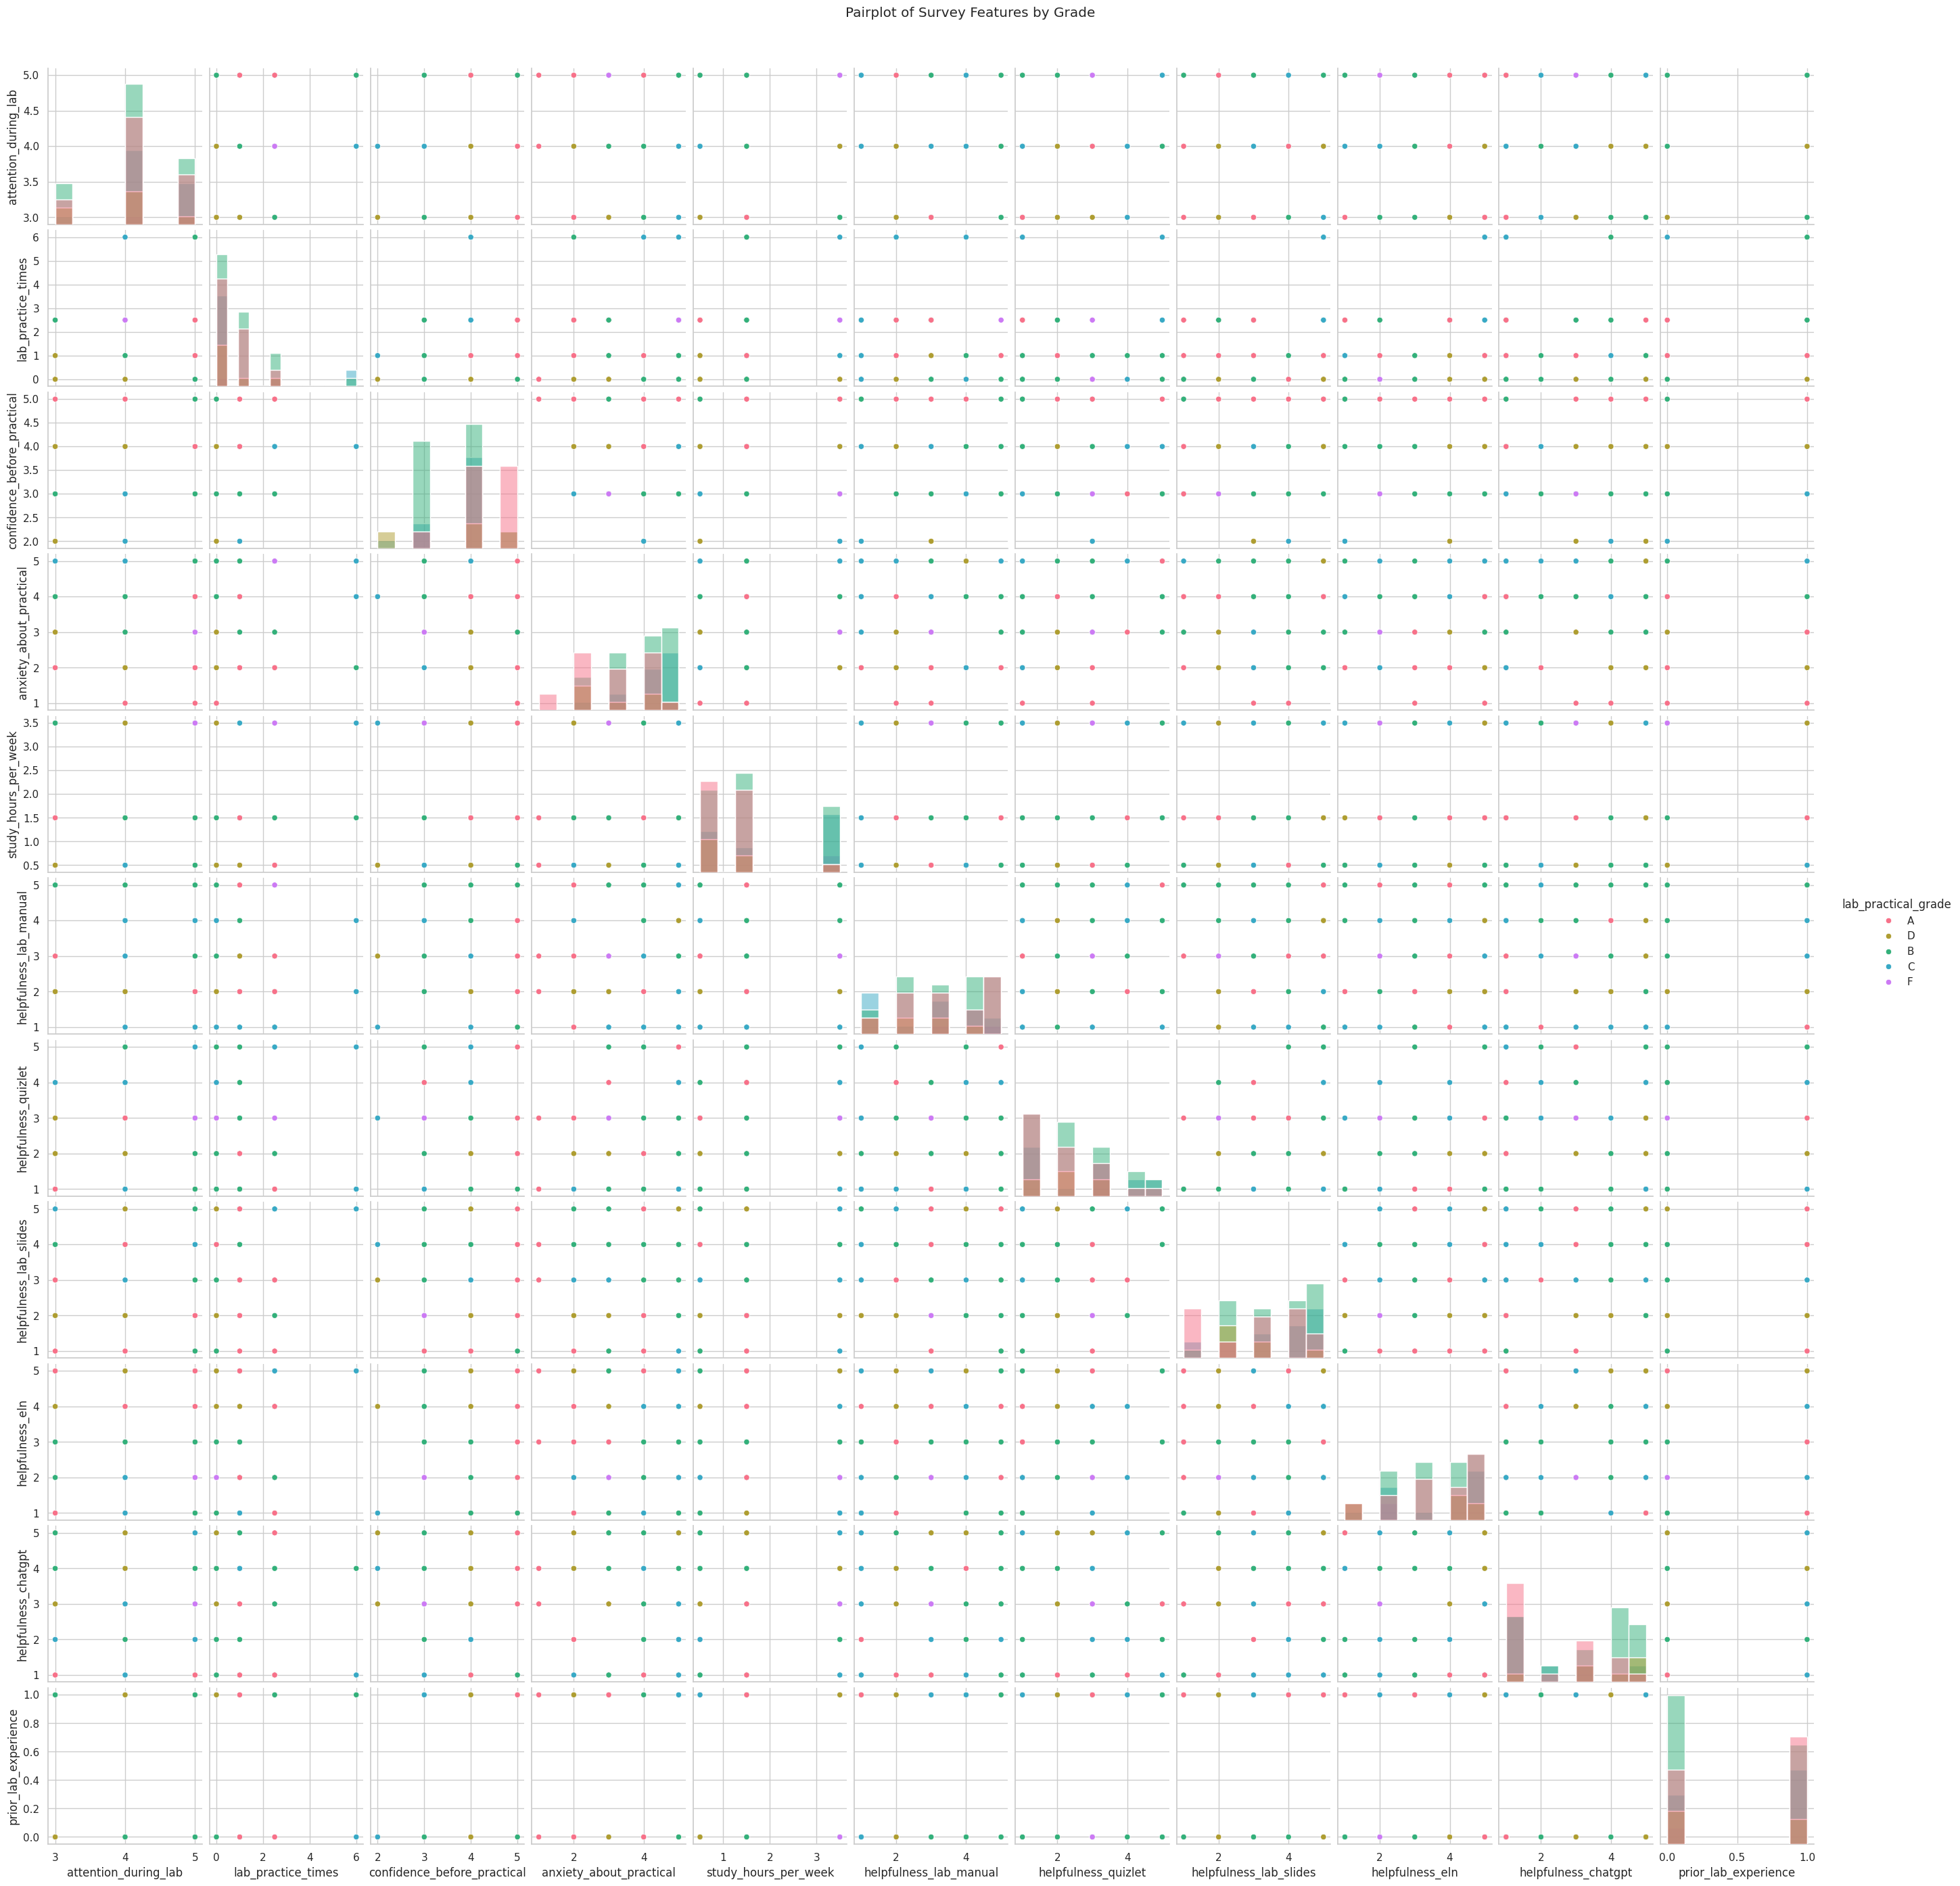

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

# Grab just the numeric features (drop grade for now)
features_for_pairplot = df.drop(columns=["lab_practical_grade"]).select_dtypes(include=[float, int])

# Add grade back in for coloring
pairplot_data = features_for_pairplot.copy()
pairplot_data["lab_practical_grade"] = df["lab_practical_grade"]

# Plot
sns.pairplot(pairplot_data, hue="lab_practical_grade", palette="husl", diag_kind="hist")
plt.suptitle("Pairplot of Survey Features by Grade", y=1.02)
plt.show()


## Quick Look at Some Results So Far

Before we jump into splitting the data or running models, here are a few early visuals based on the cleaned survey data:

- The **grade distribution** shows most students got A’s or B’s, with a few lower grades mixed in.
- The **study hours boxplot** suggests that higher study hours don’t necessarily mean better grades—C students studied more on average than A students.
- The **pairplot** helps us explore relationships between variables. It’s a big messy grid of scatterplots, but sometimes you can see clusters that suggest which variables might help us separate the different grade categories.

We'll keep all of this in mind as we move into modeling.
So yeah, looking at the data... clearly study time alone doesn’t explain who gets an A and who doesn’t. That’s why we’re going to train some to see if we can potentially pick up on patterns that actually matter.


## Train-Test Split + First Model (Logistic Regression)

Alright so now it’s time to train our first model. We’re starting with **Logistic Regression** because:
- It’s simple
- It runs fast
- It gives us a decent idea of what features matter

Even though logistic regression is usually used for binary classification, it can also handle multiple classes (like A/B/C/D/F) using something called *one-vs-rest*. Basically, it builds one model per class to separate it from the others.

### What we’re doing here:
1. Split the dataset into training and testing sets. We’re using 80% of the data to train and saving 20% to test how well the model does on data it hasn’t seen.
2. Train the logistic regression model on the training data.
3. Use the trained model to make predictions on the test set.
4. Check how accurate the predictions are and look at a confusion matrix to see what the model gets right or wrong for each grade.

We also made two small adjustments here:
- We suppressed warnings for undefined precision, which can happen when the model doesn’t predict certain grades at all (this is normal in small datasets).
- We made sure the confusion matrix only shows the labels that are actually in the test set, so it doesn’t break if a grade like “F” didn’t show up.


Accuracy: 31.25%
Classification Report:
              precision    recall  f1-score   support

           A       0.44      0.80      0.57         5
           B       0.25      0.17      0.20         6
           C       0.00      0.00      0.00         3
           D       0.00      0.00      0.00         2

    accuracy                           0.31        16
   macro avg       0.17      0.24      0.19        16
weighted avg       0.23      0.31      0.25        16



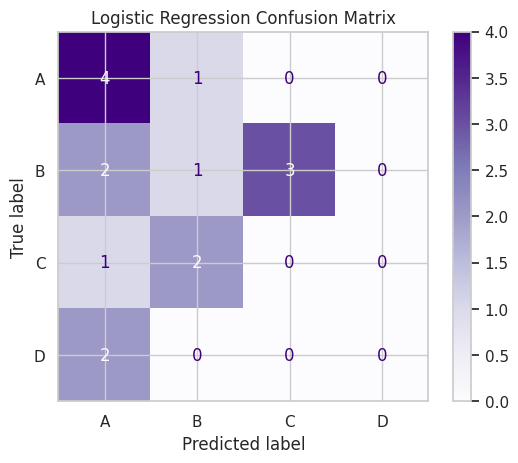

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define features and target
X = df.drop(columns=["lab_practical_grade"])
y = df["lab_practical_grade"]

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 3: Train the logistic regression model
logreg = LogisticRegression(max_iter=10000, solver="lbfgs")
logreg.fit(X_train, y_train)

# Step 4: Make predictions
y_pred = logreg.predict(X_test)

# Step 5: Evaluate performance
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Step 6: Handle label mismatch in confusion matrix
labels_in_test = np.unique(np.concatenate([y_test, y_pred]))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred, labels=labels_in_test),
    display_labels=labels_in_test
).plot(cmap="Purples")

plt.title("Logistic Regression Confusion Matrix")
plt.show()


## How Did It Do?

Not great 🥲 — the logistic regression model had an accuracy of 31%, and it really struggled with anything that wasn’t an A or B.

- It correctly predicted most A's
- It sort of guessed some B's
- It never predicted a C or D, even though they were in the test set

This tells us a few things:
- Logistic regression might be too simple for this dataset
- Some grades (like D) may not have enough examples to learn from
- We need to try models that can pick up on more complex patterns

Next up: let’s scale the data and try again.


## Scaling the Features and Re-running Logistic Regression

Logistic regression works best when all the features are on the same scale. Right now, some of our variables (like lab visits or helpfulness ratings) are on different ranges.

To fix that, we’ll use **StandardScaler** to standardize all the features. This rescales them so they have a mean of 0 and a standard deviation of 1.

We’ll then re-train logistic regression using the scaled data and see if it performs any better.


Accuracy (scaled): 31.25%
Classification Report (scaled):
              precision    recall  f1-score   support

           A       0.44      0.80      0.57         5
           B       0.25      0.17      0.20         6
           C       0.00      0.00      0.00         3
           D       0.00      0.00      0.00         2

    accuracy                           0.31        16
   macro avg       0.17      0.24      0.19        16
weighted avg       0.23      0.31      0.25        16



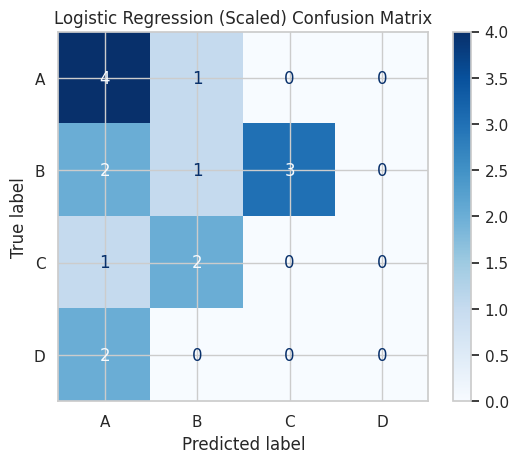

In [57]:
from sklearn.preprocessing import StandardScaler

# Step 1: Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2: Train logistic regression on scaled data
logreg_scaled = LogisticRegression(max_iter=10000, solver="lbfgs")
logreg_scaled.fit(X_train_scaled, y_train)

# Step 3: Predict and evaluate
y_pred_scaled = logreg_scaled.predict(X_test_scaled)

print(f"Accuracy (scaled): {accuracy_score(y_test, y_pred_scaled)*100:.2f}%")
print("Classification Report (scaled):")
print(classification_report(y_test, y_pred_scaled, zero_division=0))

# Step 4: Confusion matrix with dynamic labels
labels_in_scaled_test = np.unique(np.concatenate([y_test, y_pred_scaled]))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_scaled, labels=labels_in_scaled_test),
    display_labels=labels_in_scaled_test
).plot(cmap="Blues")

plt.title("Logistic Regression (Scaled) Confusion Matrix")
plt.show()


## Did Scaling Help?

Not really 😬

We re-ran logistic regression after scaling the data, but the results didn’t improve. The model is still mostly just predicting A and B, and completely misses C and D.

This confirms that logistic regression probably isn’t the right fit for our dataset — it’s just too simple to capture the patterns here.

Next up, we’re going to try a non-linear model that can handle this kind of data better: **Decision Trees** 🌳


## Trying a Decision Tree Classifier

Logistic regression was a solid baseline, but it’s clearly not enough for this dataset.

Now we’re trying a **Decision Tree Classifier**, which is a non-linear model that can handle more complex patterns. It doesn’t require scaling, and it can even work well on small datasets.

We’ll train the tree, make predictions, and check if it does a better job catching those C’s and D’s.


Accuracy (Decision Tree): 37.50%
Classification Report (Decision Tree):
              precision    recall  f1-score   support

           A       0.50      0.40      0.44         5
           B       0.33      0.50      0.40         6
           C       0.50      0.33      0.40         3
           D       0.00      0.00      0.00         2
           F       0.00      0.00      0.00         0

    accuracy                           0.38        16
   macro avg       0.27      0.25      0.25        16
weighted avg       0.38      0.38      0.36        16



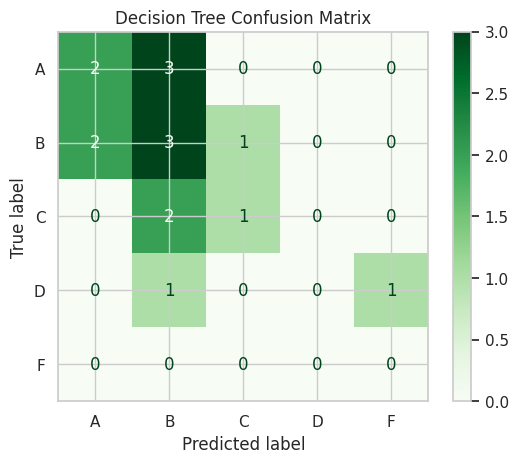

In [58]:
from sklearn.tree import DecisionTreeClassifier

# Step 1: Train the decision tree
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

# Step 2: Make predictions
y_pred_tree = tree.predict(X_test)

# Step 3: Evaluate
print(f"Accuracy (Decision Tree): {accuracy_score(y_test, y_pred_tree)*100:.2f}%")
print("Classification Report (Decision Tree):")
print(classification_report(y_test, y_pred_tree, zero_division=0))

# Step 4: Confusion matrix
labels_in_tree_test = np.unique(np.concatenate([y_test, y_pred_tree]))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_tree, labels=labels_in_tree_test),
    display_labels=labels_in_tree_test
).plot(cmap="Greens")

plt.title("Decision Tree Confusion Matrix")
plt.show()


## How Did the Decision Tree Do?

This is already better than logistic regression. Is it great? No. But improvement is better than no improvement. 

So :

- It predicted a wider range of grades (finally something other than A/B)
- It correctly guessed a C and even got a D and F
- The accuracy went up slightly — not amazing, but an improvement

This tells us the model can now recognize more complex patterns, and isn’t just guessing the majority class.

Next we’ll try to make it even better using a **Random Forest**, which is basically a bunch of decision trees working together.


## Trying a Random Forest

A decision tree helped, but a **Random Forest** might do even better.

Random forests are made up of a bunch of individual decision trees that all vote on the final prediction. They’re more stable, less prone to overfitting, and often more accurate than a single tree.

Let’s train one and see if it can boost performance.


Accuracy (Random Forest): 31.25%
Classification Report (Random Forest):
              precision    recall  f1-score   support

           A       0.40      0.40      0.40         5
           B       0.30      0.50      0.38         6
           C       0.00      0.00      0.00         3
           D       0.00      0.00      0.00         2

    accuracy                           0.31        16
   macro avg       0.17      0.23      0.19        16
weighted avg       0.24      0.31      0.27        16



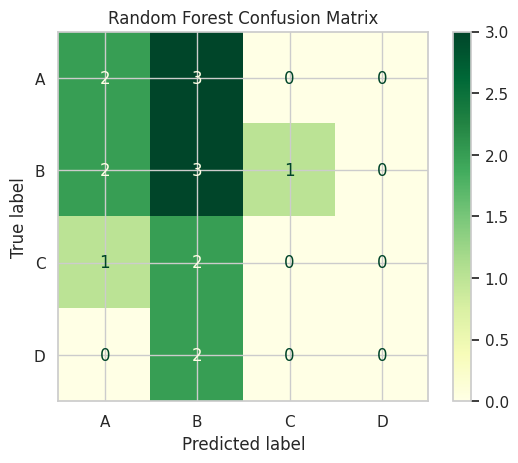

In [59]:
from sklearn.ensemble import RandomForestClassifier

# Step 1: Train the random forest
forest = RandomForestClassifier(random_state=42, n_estimators=100)
forest.fit(X_train, y_train)

# Step 2: Make predictions
y_pred_forest = forest.predict(X_test)

# Step 3: Evaluate
print(f"Accuracy (Random Forest): {accuracy_score(y_test, y_pred_forest)*100:.2f}%")
print("Classification Report (Random Forest):")
print(classification_report(y_test, y_pred_forest, zero_division=0))

# Step 4: Confusion matrix
labels_in_forest_test = np.unique(np.concatenate([y_test, y_pred_forest]))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_forest, labels=labels_in_forest_test),
    display_labels=labels_in_forest_test
).plot(cmap="YlGn")

plt.title("Random Forest Confusion Matrix")
plt.show()


## Random Forest Results

We were hoping a random forest would boost performance by combining multiple trees — but honestly, it didn’t help much.

- It still focused mostly on predicting B's
- It ignored C and D completely
- Accuracy stayed the same as before (31.25%)

> “Let’s just guess B for everything and call it a day.”  
> —Random Forest, 2025

At this point, it's clear that:
- The models are struggling because of our small dataset
- Some classes (like D and F) just don’t have enough examples to learn from

We could try tuning hyperparameters to improve things.